In [ ]:
# Should be exec first
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

In [2]:
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

In [3]:
save_dir = f'{FIG_ROOT}/liver_hpi/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Get predicted ctrl, uninfected and Infected of OOD settings

In [4]:
adata_observed = sc.read_h5ad('../../Datasets/preprocessed_datasets/liver.h5ad')
adata_predicted = None
for a_file in tqdm(['pred_ctrl_Pericentral.h5ad', 'pred_ctrl_Periportal.h5ad', 'pred_infected_Pericentral.h5ad',
              'pred_infected_Periportal.h5ad', 'pred_uninfected_Pericentral.h5ad', 
              'pred_uninfected_Periportal.h5ad']):
    _adata_pred = sc.read_h5ad(a_file)
    if adata_predicted is None:
        adata_predicted = _adata_pred.copy()
    else:
        adata_predicted = ad.concat([adata_predicted, _adata_pred])

  0%|                                                                                                                                                                                        | 0/6 [00:00<?, ?it/s]/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
 50%|████████████████████████████████████████████████████████████████████████████████████████            

In [5]:
adata_predicted.X.max()

14468.656

# Normalize

In [6]:
sc.pp.log1p(adata_observed)
sc.pp.log1p(adata_predicted)

adata.X seems to be already log-transformed.


# Concat

In [7]:
adata_observed.obs['y'] = 'Observed'
adata_predicted.obs['y'] = 'Predicted'
adata_cat = ad.concat([adata_observed, adata_predicted])

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/merge.py:1362: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# UMAP on concat gt & pred

In [8]:
sc.pp.neighbors(adata_cat)
sc.tl.umap(adata_cat)

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 8203 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
2026-02-25 07:08:37.123518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-25 07:08:37.133325: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factor

# Plot Control cells and Infected cells across all time-points post-infection (GT)

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


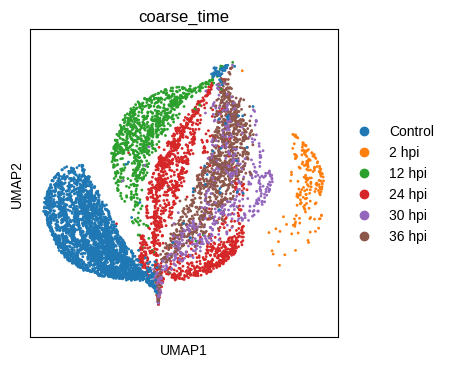

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))

sc.pl.umap(
    adata_cat[(adata_cat.obs['status_control'] != 'Uninfected') & (adata_cat.obs['y'] == 'Observed')],
    color=['coarse_time'],
    show=False,
    ax=ax
)


# Rasterize ONLY the scatter points
for coll in ax.collections:
    coll.set_rasterized(True)

ax.set_aspect('equal')
ax.set_box_aspect(1)

plt.savefig(f'{save_dir}infected_ctrl_gt_log.png', dpi=600, bbox_inches='tight')
plt.savefig(f'{save_dir}infected_ctrl_gt_log.svg', dpi=600, bbox_inches='tight')

# Plot Control cells and Infected cells across all time-points post-infection (Pred)

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


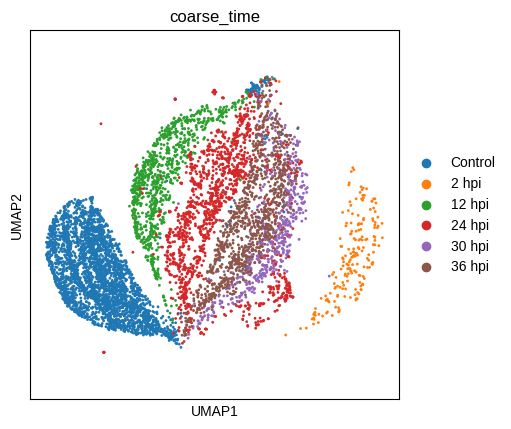

In [10]:
fig, ax = plt.subplots()

sc.pl.umap(
    adata_cat[(adata_cat.obs['status_control'] != 'Uninfected') & (adata_cat.obs['y'] == 'Predicted')],
    color=['coarse_time'],
    show=False,
    ax=ax
)

# Rasterize ONLY the scatter points
for coll in ax.collections:
    coll.set_rasterized(True)
    
ax.set_aspect('equal')
ax.set_box_aspect(1)

plt.savefig(f'{save_dir}infected_ctrl_pred_log.png', dpi=600, bbox_inches='tight')
plt.savefig(f'{save_dir}infected_ctrl_pred_log.svg', dpi=600, bbox_inches='tight')